In this notebook we try to train simple SR model
This is unfinished, currently model is not learning/something does not work

In [1]:
import xarray as xr

area_path = "data/northamerica-west-mini/"
data_in_area = xr.open_zarr(area_path + "train_data_in.zarr")
data_out_area = xr.open_zarr(area_path + "train_data_out.zarr")
static_variables = xr.open_dataset(area_path + "static_variables.nc")

In [27]:
data_in_area

<xarray.Dataset> Size: 46MB
Dimensions:    (time: 100, latitude: 80, longitude: 80)
Coordinates:
  * time       (time) datetime64[ns] 800B 2001-01-01 ... 2001-01-05T03:00:00
  * latitude   (latitude) float32 320B 60.0 59.75 59.5 ... 40.75 40.5 40.25
  * longitude  (longitude) float32 320B 230.0 230.2 230.5 ... 249.2 249.5 249.8
Data variables:
    cape       (time, latitude, longitude) float64 5MB ...
    cp         (time, latitude, longitude) float64 5MB ...
    sp         (time, latitude, longitude) float64 5MB ...
    tclw       (time, latitude, longitude) float64 5MB ...
    tcw        (time, latitude, longitude) float64 5MB ...
    tisr       (time, latitude, longitude) float64 5MB ...
    tp         (time, latitude, longitude) float64 5MB ...
    u          (time, latitude, longitude) float64 5MB ...
    v          (time, latitude, longitude) float64 5MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-06-05 08:11:26 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [28]:
data_out_area

<xarray.Dataset> Size: 16MB
Dimensions:        (time: 100, latitude: 200, longitude: 200)
Coordinates:
  * latitude       (latitude) float32 800B 59.95 59.85 59.75 ... 40.15 40.05
  * longitude      (longitude) float32 800B 230.1 230.2 230.2 ... 249.9 250.0
Dimensions without coordinates: time
Data variables:
    precipitation  (time, latitude, longitude) float32 16MB 0.0 0.0 ... 0.0 0.0

In [4]:
static_variables

<xarray.Dataset> Size: 642kB
Dimensions:    (latitude: 200, longitude: 200)
Coordinates:
  * latitude   (latitude) float32 800B 60.0 59.9 59.8 59.7 ... 40.3 40.2 40.1
  * longitude  (longitude) float32 800B 230.0 230.1 230.2 ... 249.7 249.8 249.9
    time       datetime64[ns] 8B ...
Data variables:
    lsm        (latitude, longitude) float64 320kB ...
    z          (latitude, longitude) float64 320kB ...
Attributes:
    units:          (0 - 1)
    long_name:      Land-sea mask
    standard_name:  land_binary_mask

In [29]:
print("data_in dims:", dict(data_in_area.dims))
print("data_out dims:", dict(data_out_area.dims))
print("static dims:", dict(static_variables.dims))
print("data_in times:", data_in_area.time.values.min(), data_in_area.time.values.max())


data_in dims: {'time': 100, 'latitude': 80, 'longitude': 80}
data_out dims: {'time': 100, 'latitude': 200, 'longitude': 200}
static dims: {'latitude': 200, 'longitude': 200}
data_in times: 2001-01-01T00:00:00.000000000 2001-01-05T03:00:00.000000000


/tmp/ipykernel_2394169/1742526123.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("data_in dims:", dict(data_in_area.dims))
/tmp/ipykernel_2394169/1742526123.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("data_out dims:", dict(data_out_area.dims))
/tmp/ipykernel_2394169/1742526123.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("static dims:", dict(static_vari

In [111]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Prepare Data

# Temporal split (2000-2020 train, 2021-2022 test)
times = pd.to_datetime(data_in_area.time.values)
train_mask = (times.year >= 2000) & (times.year <= 2020)
test_mask = (times.year >= 2021) & (times.year <= 2022)

# Fallback for the mini subset if it only contains 2001
if test_mask.sum() == 0:
    print("Warning: No testing data found for 2021-2022 in this subset. Falling back to an 80/20 train/test split on available data.")
    indices = np.arange(len(times))
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
else:
    train_idx = np.where(train_mask)[0]
    test_idx = np.where(test_mask)[0]

# Convert precip to mm (x 1000) and log transform
data_in_area['cp'] = np.log(data_in_area['cp'] * 1000.0 + 1e-5)
data_in_area['tp'] = np.log(data_in_area['tp'] * 1000.0 + 1e-5)

in_vars = ['cape', 'cp', 'sp', 'tclw', 'tcw', 'tisr', 'tp', 'u', 'v']
static_vars = list(static_variables.data_vars.keys())

# Dynamic features: shape (time, features, lat_in, lon_in)
dyn_features = np.stack([data_in_area[var].values for var in in_vars], axis=1) # (time, channels, lat, lon)
dyn_features_means = np.nanmean(dyn_features[train_idx], axis=(0, 2, 3), keepdims=True) # (1, channels, 1, 1)
dyn_features_stds = np.nanstd(dyn_features[train_idx], axis=(0, 2, 3), keepdims=True) + 1e-5 # (1, channels, 1, 1)

# Static features: shape (features, lat_out, lon_out)
stat_features = np.stack([static_variables[var].values for var in static_vars], axis=0) # (channels, lat, lon)
stat_features_means = np.nanmean(stat_features, axis=(1, 2), keepdims=True) # (channels, 1, 1)
stat_features_stds = np.nanstd(stat_features, axis=(1, 2), keepdims=True) + 1e-5 # (channels, 1, 1)

# Target features: shape (time, 1, lat_out, lon_out)
target = data_out_area['precipitation'].values[:, np.newaxis, :, :] # (time, 1, lat, lon)

target_log = np.log(target + 1e-5)
target_log_means = np.nanmean(target_log[train_idx], axis=(0, 2, 3), keepdims=True) # (1, 1, 1, 1)
target_log_stds = np.nanstd(target_log[train_idx], axis=(0, 2, 3), keepdims=True) + 1e-5 # (1, 1, 1, 1)

valid_mask = ~np.isnan(target)

dyn_features = np.nan_to_num(dyn_features, nan=0.0)
stat_features = np.nan_to_num(stat_features, nan=0.0)
target = np.nan_to_num(target, nan=0.0)


# Convert to Tensors
X_dyn_train = torch.tensor(dyn_features[train_idx], dtype=torch.float32)
y_train = torch.tensor(target[train_idx], dtype=torch.float32)
mask_train = torch.tensor(valid_mask[train_idx], dtype=torch.bool)

X_dyn_test = torch.tensor(dyn_features[test_idx], dtype=torch.float32)
y_test = torch.tensor(target[test_idx], dtype=torch.float32)
mask_test = torch.tensor(valid_mask[test_idx], dtype=torch.bool)

X_stat = torch.tensor(stat_features, dtype=torch.float32)

print("X_dyn_train shape:", X_dyn_train.shape)
print("X_stat shape:", X_stat.shape)
print("y_train shape:", y_train.shape)

dataset = TensorDataset(X_dyn_train, y_train, mask_train)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)


X_dyn_train shape: torch.Size([80, 9, 80, 80])
X_stat shape: torch.Size([2, 200, 200])
y_train shape: torch.Size([80, 1, 200, 200])


In [ ]:
from tqdm import tqdm

# Define Upsampling ResNet Architecture
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        
    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))

class UpsampleResNet(nn.Module):
    def __init__(self, in_channels, static_channels, out_channels=1, hidden_channels=64):
        super().__init__()
        
        # Initial feature extraction on coarse grid
        self.entry = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.res1 = ResBlock(hidden_channels)
        
        # Post-upsampling convolution combining dynamic and static features
        self.post_up_conv = nn.Conv2d(hidden_channels + static_channels, hidden_channels, kernel_size=3, padding=1)
        self.res2 = nn.Sequential(
            ResBlock(hidden_channels),
            ResBlock(hidden_channels)
        )
        self.exit = nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=1)
        
    def forward(self, x, x_static, target_size=(200, 200)):
        x = self.relu(self.entry(x))
        x = self.res1(x)
        
        # Spatially upsample coarse features to target high-res grid via interpolation
        x_up = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
        
        # Expand static features to match batch size and concatenate
        x_s = x_static.unsqueeze(0).expand(x_up.size(0), -1, -1, -1)
        x_combined = torch.cat([x_up, x_s], dim=1)
        
        # Further processing
        out = self.relu(self.post_up_conv(x_combined))
        out = self.res2(out)
        out = self.exit(out)
        return out

# Feature Normalization Class
class Normalize:
    def __init__(self, means, stds, device):
        self.means = torch.tensor(means, dtype=torch.float32).to(device)
        self.stds = torch.tensor(stds, dtype=torch.float32).to(device)

    def __call__(self, x):
        return (x - self.means) / self.stds
    
    def revert(self, x):
        return x * self.stds + self.means

In [118]:
# Training Loop Setup

input_dim = X_dyn_train.shape[1]
static_dim = X_stat.shape[0]
target_img_size = (y_train.shape[2], y_train.shape[3])

model = UpsampleResNet(in_channels=input_dim, static_channels=static_dim)
print(model)

criterion = nn.MSELoss(reduction='none') 
optimizer = optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

# dyn and target based on training split statistics
dyn_feature_normalizer = Normalize(dyn_features_means, dyn_features_stds, device)
stat_feature_normalizer = Normalize(stat_features_means, stat_features_stds, device)
target_normalizer = Normalize(target_log_means, target_log_stds, device)

X_stat_device = X_stat.to(device)
X_stat_device = stat_feature_normalizer(X_stat_device) # normalize

def train_model(model, dataloader, epochs=5):
    model.train()
    losses = []
    
    for epoch in tqdm(range(epochs)):
        epoch_loss = 0
        total_batches = 0
        for batch_X, batch_y, batch_mask in dataloader:
            batch_X, batch_y, batch_mask = batch_X.to(device), batch_y.to(device), batch_mask.to(device)
            
            # normalize before passing into model
            batch_X = dyn_feature_normalizer(batch_X)
            batch_y = target_normalizer(torch.log(batch_y + 1e-5)) # log-transform + normalize
            
            optimizer.zero_grad()
            outputs = model(batch_X, X_stat_device, target_img_size)
            
            # Mask out invalid pixels (NaN targets)
            loss_elements = criterion(outputs, batch_y)
            loss = loss_elements[batch_mask].mean()
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            total_batches += 1
            
        avg_loss = epoch_loss / total_batches
        losses.append(avg_loss)
        if epoch % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    return losses


UpsampleResNet(
  (entry): Conv2d(9, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU(inplace=True)
  (res1): ResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (post_up_conv): Conv2d(66, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (res2): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (exit): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [120]:
# Train the model
losses = train_model(model, dataloader, epochs=500)

  0%|          | 2/500 [00:00<00:46, 10.61it/s]

Epoch 1/500, Loss: 27.1496


 10%|█         | 52/500 [00:04<00:40, 11.16it/s]

Epoch 51/500, Loss: 7.2209


 20%|██        | 102/500 [00:09<00:35, 11.07it/s]

...

 80%|████████  | 402/500 [00:36<00:08, 11.13it/s]

Epoch 401/500, Loss: 1.1416


 90%|█████████ | 452/500 [00:40<00:04, 11.09it/s]

Epoch 451/500, Loss: 1.0936


100%|██████████| 500/500 [00:44<00:00, 11.12it/s]


In [115]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

def evaluate_and_plot(y_test, y_pred, model_name):
    # Absolute Errors
    abs_errors = np.abs(y_test - y_pred)
    
    # Deterministic CRPS is exactly equivalent to MAE
    mae_crps = mean_absolute_error(y_test, y_pred)
    
    # Percentiles
    mae_95 = np.percentile(abs_errors, 95)
    mae_99 = np.percentile(abs_errors, 99)
    
    print(f"--- {model_name} ---")
    print(f"Deterministic CRPS (MAE): {mae_crps:.4f}")
    print(f"95th Percentile MAE: {mae_95:.4f}")
    print(f"99th Percentile MAE: {mae_99:.4f}")
    print()
    
    # Scatter plot
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.3, s=10, edgecolors='none')
    
    # Identity line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y=x)')
    
    plt.xlabel('Actual Precipitation [mm]')
    plt.ylabel('Predicted Precipitation [mm]')
    plt.title(f'{model_name}: Predicted vs Actual')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return mae_crps, mae_95, mae_99


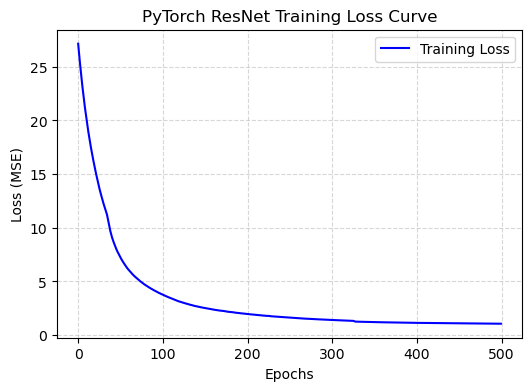

orig: tensor(-33.3002, device='cuda:0') tensor(317.9316, device='cuda:0')
reverted: tensor(-151.9890) tensor(1354.6494)
exp: tensor(-1.0000e-05) tensor(inf)
--- PyTorch Downscale ResNet ---
Deterministic CRPS (MAE): 0.1549
95th Percentile MAE: 0.5549
99th Percentile MAE: 2.6599



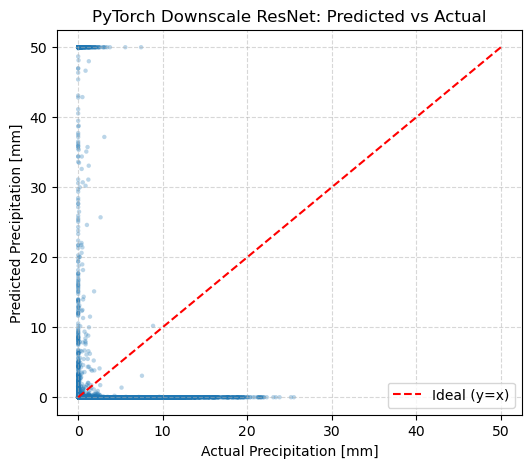

(0.1549314260482788, np.float32(0.55490184), np.float32(2.6599016))

In [122]:
# Plot Training Loss
plt.figure(figsize=(6, 4))
plt.plot(losses, label='Training Loss', color='blue')
plt.title('PyTorch ResNet Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Predict on Test Set using ResNet
model.eval()
X_dyn_test = X_dyn_test.to(device)
with torch.no_grad():
    # Pass batched 2D images
    test_outputs = model(dyn_feature_normalizer(X_dyn_test), X_stat_device, target_img_size)

# revert normalization to inspect in original scale
print("orig:", test_outputs.min(), test_outputs.max())
test_outputs = target_normalizer.revert(test_outputs).cpu()
print("reverted:", test_outputs.min(), test_outputs.max())
test_outputs = torch.exp(test_outputs) - 1e-5 # revert log-transform
print("exp:", test_outputs.min(), test_outputs.max())
test_outputs = torch.clamp(test_outputs, min=0.0, max=50) # clamp for evaluation
# print(test_outputs.min(), test_outputs.max())

# Transfer back to CPU
y_pred_cpu = test_outputs.cpu()

# Flatten and extract only valid pixels covered by the mask
y_pred_flat = y_pred_cpu[mask_test].numpy().flatten()
y_true_flat = y_test[mask_test].numpy().flatten()

# Evaluate Metrics and Plot
evaluate_and_plot(y_true_flat, y_pred_flat, "PyTorch Downscale ResNet")


In [97]:
y_true_flat.min(), y_true_flat.max()

(np.float32(0.0), np.float32(25.515))

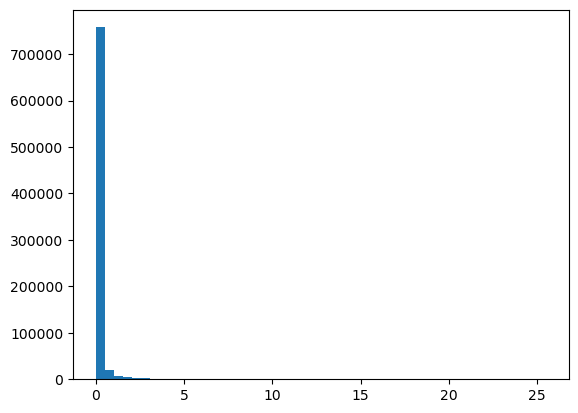

In [103]:
# plt.hist(y_pred_flat)
plt.hist(y_true_flat, bins=50)
plt.show()